# 🏆 Ejercicio Global — Tema 2: Transformaciones de Datos
## Diplomado en Machine Learning en Seguros

### Contexto
Eres actuario en una aseguradora de **autos en México**. Recibes un dataset crudo de pólizas 
y siniestros del año 2024 y debes prepararlo para un modelo predictivo de siniestralidad.

### Objetivos
1. ✅ Calcular variables derivadas actuariales (edad, exposición, antigüedad)
2. ✅ Codificar variables categóricas apropiadamente
3. ✅ Aplicar transformaciones a variables asimétricas  
4. ✅ Escalar variables numéricas
5. ✅ Hacer feature engineering con efectos calendario y segmentación de riesgo
6. ✅ Construir el dataset final listo para modelar

### Dataset
Portfolio de 2,000 pólizas con información de conductor, vehículo, póliza y siniestros.

---


In [2]:
# SETUP: Importar todas las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from scipy.stats import boxcox, yeojohnson
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
pd.set_option('display.float_format', '{:,.2f}'.format)
print("✅ Librerías cargadas — ¡Comenzamos!")


✅ Librerías cargadas — ¡Comenzamos!


In [3]:
# ═══════════════════════════════════════════════════════
# PASO 0: CARGAR Y EXPLORAR EL DATASET CRUDO
# ═══════════════════════════════════════════════════════
np.random.seed(2024)
N = 2000

municipios_nl = ['Monterrey', 'San Pedro Garza García', 'Guadalupe', 'Apodaca', 
                 'General Escobedo', 'Santa Catarina', 'Juárez', 'García',
                 'San Nicolás de los Garza', 'Linares']
coberturas = ['Básica', 'Amplia', 'Total Plus']
marcas = ['Toyota', 'Nissan', 'Chevrolet', 'Honda', 'Ford', 'Volkswagen', 
          'Hyundai', 'Kia', 'Mazda', 'SEAT', 'Jeep', 'Dodge']
tipos_uso = ['Particular', 'Comercial', 'Transporte']
profesiones = ['Empleado', 'Empresario', 'Profesionista', 'Comerciante', 'Estudiante', 'Otro']

def fecha_random(inicio, fin, n):
    dias = (pd.Timestamp(fin) - pd.Timestamp(inicio)).days
    return pd.Timestamp(inicio) + pd.to_timedelta(np.random.randint(0, dias, n), unit='d')

fechas_nacimiento = fecha_random('1960-01-01', '2005-12-31', N)
fechas_inicio = fecha_random('2019-01-01', '2024-01-01', N)
fechas_fin = fechas_inicio + pd.to_timedelta(np.random.choice([365, 365, 365, 180, 730], N), unit='d')
fechas_primera = fechas_inicio - pd.to_timedelta(np.random.randint(0, 3650, N), unit='d')

# Simular siniestros con estacionalidad real
prob_siniestro = np.random.uniform(0.05, 0.45, N)
num_siniestros = np.array([np.random.binomial(1, min(p, 0.45)) for p in prob_siniestro])
monto_siniestros = np.where(
    num_siniestros > 0,
    np.random.lognormal(9.8, 1.0, N),
    0
)

df_raw = pd.DataFrame({
    'id_poliza': [f'POL-{2024000 + i}' for i in range(N)],
    'fecha_nacimiento_conductor': fechas_nacimiento,
    'fecha_inicio_vigencia': fechas_inicio,
    'fecha_fin_vigencia': pd.to_datetime(np.where(
        fechas_fin > pd.Timestamp('2024-12-31'),
        pd.Timestamp('2024-12-31'),
        fechas_fin
    )),
    'fecha_primera_poliza': fechas_primera,
    'municipio': np.random.choice(municipios_nl, N, p=[0.22,0.10,0.18,0.12,0.08,0.08,0.07,0.06,0.06,0.03]),
    'cobertura': np.random.choice(coberturas, N, p=[0.38, 0.40, 0.22]),
    'marca_vehiculo': np.random.choice(marcas, N),
    'anio_modelo_vehiculo': np.random.randint(2005, 2025, N),
    'tipo_uso': np.random.choice(tipos_uso, N, p=[0.82, 0.12, 0.06]),
    'sexo': np.random.choice(['M', 'F'], N, p=[0.60, 0.40]),
    'profesion': np.random.choice(profesiones, N, p=[0.40, 0.12, 0.18, 0.15, 0.08, 0.07]),
    'suma_asegurada': np.random.lognormal(12.8, 0.5, N).clip(100000, 3000000),
    'prima_anual': np.random.lognormal(9.9, 0.5, N).clip(6000, 120000),
    'descuento_comercial': np.random.uniform(0, 0.25, N),
    'num_siniestros': num_siniestros,
    'monto_siniestros': monto_siniestros,
    'num_siniestros_previos_3anios': np.random.poisson(0.3, N),
    'monto_siniestros_previos_3anios': np.random.lognormal(8.5, 1, N) * np.random.poisson(0.3, N),
})

print(f"📋 Dataset crudo: {df_raw.shape[0]} pólizas, {df_raw.shape[1]} variables")
print("\n🔍 Primeras 5 filas:")
print(df_raw.head(5).to_string())
print("\n📊 Tipos de datos:")
print(df_raw.dtypes)


📋 Dataset crudo: 2000 pólizas, 19 variables

🔍 Primeras 5 filas:
     id_poliza fecha_nacimiento_conductor fecha_inicio_vigencia fecha_fin_vigencia fecha_primera_poliza               municipio cobertura marca_vehiculo  anio_modelo_vehiculo    tipo_uso sexo      profesion  suma_asegurada  prima_anual  descuento_comercial  num_siniestros  monto_siniestros  num_siniestros_previos_3anios  monto_siniestros_previos_3anios
0  POL-2024000                 1981-05-26            2023-06-19         2024-06-18           2020-10-29               Monterrey    Amplia        Hyundai                  2017  Particular    F       Empleado      327,649.03    14,391.61                 0.20               1          6,661.74                              0                         4,175.52
1  POL-2024001                 1967-05-12            2022-07-14         2023-01-10           2020-01-15  San Pedro Garza García    Básica            Kia                  2013   Comercial    F       Empleado      520,048.85   

In [18]:
# ═══════════════════════════════════════════════════════
# PASO 1: VARIABLES DERIVADAS ACTUARIALES (Tema 2.4)
# ═══════════════════════════════════════════════════════
print("🔧 PASO 1: Calculando variables derivadas actuariales...")
FECHA_EVAL = pd.Timestamp('2024-12-31')
df = df_raw.copy()

# 1.1 Edad del conductor
df['edad_conductor'] = (FECHA_EVAL - df['fecha_nacimiento_conductor']).dt.days / 365.25
df['edad_conductor_int'] = df['edad_conductor'].astype(int)

# 1.2 Exposición en años
df['exposicion_dias'] = (df['fecha_fin_vigencia'] - df['fecha_inicio_vigencia']).dt.days.clip(0)
df['exposicion_anios'] = df['exposicion_dias'] / 365.25

# 1.2BIS Exposición actualizada al 31/12/2024

df['exposicion_dias_HOY'] = np.where(
    df['fecha_fin_vigencia'] >= FECHA_EVAL,
    (FECHA_EVAL - df['fecha_inicio_vigencia']).dt.days.clip(0),
    df['exposicion_dias']
)
df['exposicion_anios_HOY'] = df['exposicion_dias_HOY'] / 365.25


# 1.3 Antigüedad del cliente
df['antiguedad_cliente_anios'] = ((df['fecha_inicio_vigencia'] - df['fecha_primera_poliza']).dt.days / 365.25).clip(0)

# 1.4 Antigüedad del vehículo
df['antiguedad_vehiculo_anios'] = 2024 - df['anio_modelo_vehiculo']

# 1.5 Variables de vigencia (mes de inicio y fin)
df['mes_inicio'] = df['fecha_inicio_vigencia'].dt.month
df['mes_fin'] = df['fecha_fin_vigencia'].dt.month

# 1.6 Frecuencia y severidad previas
epsilon = 1e-8
df['frecuencia_previa'] = df['num_siniestros_previos_3anios'] / (df['antiguedad_cliente_anios'].clip(lower=0.1))
df['severidad_previa'] = np.where(
    df['num_siniestros_previos_3anios'] > 0,
    df['monto_siniestros_previos_3anios'] / df['num_siniestros_previos_3anios'],
    0
)

print(f"✅ Variables derivadas calculadas:")
nuevas = ['edad_conductor', 'exposicion_anios','exposicion_anios_HOY','antiguedad_cliente_anios', 
          'antiguedad_vehiculo_anios', 'frecuencia_previa', 'severidad_previa']
print(df[nuevas].describe().round(3))


🔧 PASO 1: Calculando variables derivadas actuariales...
✅ Variables derivadas calculadas:
       edad_conductor  exposicion_anios  exposicion_anios_HOY  \
count        2,000.00          2,000.00              2,000.00   
mean            42.31              1.09                  1.09   
std             13.42              0.48                  0.48   
min             19.02              0.49                  0.49   
25%             30.70              1.00                  1.00   
50%             42.50              1.00                  1.00   
75%             54.06              1.00                  1.00   
max             64.96              2.00                  2.00   

       antiguedad_cliente_anios  antiguedad_vehiculo_anios  frecuencia_previa  \
count                  2,000.00                   2,000.00           2,000.00   
mean                       4.97                       9.51               0.19   
std                        2.86                       5.79               1.20   


In [14]:
# 1.2BIS Exposición actualizada al 31/12/2024

mask_vigente = df['fecha_fin_vigencia'] > FECHA_EVAL
df['vigencia'] = mask_vigente.astype(int).map({1: 'Vigente', 0: 'No Vigente'})
df['exposicion_dias_HOY'] = (FECHA_EVAL - df['fecha_inicio_vigencia']).dt.days.clip(0)
df['exposicion_anios_HOY'] = df['exposicion_dias_HOY'] / 365.25

In [5]:
# ═══════════════════════════════════════════════════════
# PASO 2: VARIABLES DUMMY ACTUARIALES (Tema 2.4)
# ═══════════════════════════════════════════════════════
print("🔧 PASO 2: Creando variables dummy actuariales...")

df['es_renovacion'] = (df['antiguedad_cliente_anios'] > 1).astype(int)
df['tiene_siniestro_previo'] = (df['num_siniestros_previos_3anios'] > 0).astype(int)
df['es_conductor_joven'] = (df['edad_conductor_int'] < 26).astype(int)
df['es_adulto_mayor'] = (df['edad_conductor_int'] >= 65).astype(int)
df['es_uso_comercial'] = df['tipo_uso'].isin(['Comercial', 'Transporte']).astype(int)
df['vehiculo_antiguo'] = (df['antiguedad_vehiculo_anios'] >= 10).astype(int)
df['poliza_anual'] = (df['exposicion_dias'] >= 350).astype(int)

# NCD Score (No Claims Discount): hasta 25% de descuento
anios_limpios = np.where(df['num_siniestros_previos_3anios'] == 0, 
                          df['antiguedad_cliente_anios'].clip(0, 5), 0)
df['ncd_score'] = anios_limpios * 0.05

print("✅ Variables dummy creadas:")
dummies = ['es_renovacion', 'tiene_siniestro_previo', 'es_conductor_joven', 
           'es_adulto_mayor', 'es_uso_comercial', 'vehiculo_antiguo', 'ncd_score']
print(df[dummies].describe().round(3))


🔧 PASO 2: Creando variables dummy actuariales...
✅ Variables dummy creadas:
       es_renovacion  tiene_siniestro_previo  es_conductor_joven  \
count       2,000.00                2,000.00            2,000.00   
mean            0.91                    0.27                0.16   
std             0.28                    0.44                0.36   
min             0.00                    0.00                0.00   
25%             1.00                    0.00                0.00   
50%             1.00                    0.00                0.00   
75%             1.00                    1.00                0.00   
max             1.00                    1.00                1.00   

       es_adulto_mayor  es_uso_comercial  vehiculo_antiguo  ncd_score  
count         2,000.00          2,000.00          2,000.00   2,000.00  
mean              0.00              0.19              0.50       0.14  
std               0.00              0.39              0.50       0.11  
min               0.00 

In [ ]:
# ═══════════════════════════════════════════════════════
# PASO 3: CODIFICACIÓN DE CATEGÓRICAS (Tema 2.3)
# ═══════════════════════════════════════════════════════
print("🔧 PASO 3: Codificando variables categóricas...")

# 3.1 One-Hot Encoding — cobertura y tipo_uso (pocas categorías, sin orden)
dummies_cobertura = pd.get_dummies(df['cobertura'], prefix='cobertura', drop_first=True, dtype=int)
dummies_uso = pd.get_dummies(df['tipo_uso'], prefix='uso', drop_first=True, dtype=int)
dummies_sexo = pd.get_dummies(df['sexo'], prefix='sexo', drop_first=True, dtype=int)
df = pd.concat([df, dummies_cobertura, dummies_uso, dummies_sexo], axis=1)

# 3.2 Target Encoding — municipio y marca_vehiculo (alta cardinalidad)
media_global_sin = (df['num_siniestros'] > 0).mean()
k_suavizado = 15

for col in ['municipio', 'marca_vehiculo', 'profesion']:
    target = (df['num_siniestros'] > 0).astype(int)
    stats = target.groupby(df[col]).agg(['mean', 'count'])
    stats['encoded'] = (stats['count'] * stats['mean'] + k_suavizado * media_global_sin) / (stats['count'] + k_suavizado)
    df[f'{col}_te'] = df[col].map(stats['encoded'])

print("✅ Variables categóricas codificadas:")
te_cols = ['municipio_te', 'marca_vehiculo_te', 'profesion_te']
ohe_cols = list(dummies_cobertura.columns) + list(dummies_uso.columns) + list(dummies_sexo.columns)
print(f"  Target Encoded: {te_cols}")
print(f"  One-Hot Encoded: {ohe_cols}")
print("\n  Muestra de Target Encoding por municipio:")
te_municipio = df.groupby('municipio')['municipio_te'].first().sort_values(ascending=False)
print(te_municipio.round(4))


🔧 PASO 3: Codificando variables categóricas...
✅ Variables categóricas codificadas:
  Target Encoded: ['municipio_te', 'marca_vehiculo_te', 'profesion_te']
  One-Hot Encoded: ['cobertura_Básica', 'cobertura_Total Plus', 'uso_Particular', 'uso_Transporte', 'sexo_M']

  Muestra de Target Encoding por municipio:
municipio
San Pedro Garza García     0.30
Linares                    0.30
Santa Catarina             0.29
García                     0.29
Monterrey                  0.28
Juárez                     0.28
Guadalupe                  0.23
Apodaca                    0.22
General Escobedo           0.20
San Nicolás de los Garza   0.20
Name: municipio_te, dtype: float64


In [ ]:
# ═══════════════════════════════════════════════════════
# PASO 4: FEATURE ENGINEERING — CALENDARIO Y SEGMENTACIÓN (Tema 2.5)
# ═══════════════════════════════════════════════════════
print("🔧 PASO 4: Feature Engineering avanzado...")

# 4.1 Variables de estacionalidad (mes de inicio de póliza)
df['inicio_en_temporada_alta'] = df['mes_inicio'].isin([1, 4, 7, 12]).astype(int)
df['inicio_en_verano'] = df['mes_inicio'].isin([6, 7, 8]).astype(int)

# 4.2 Segmentación de riesgo por edad (curva U: jóvenes y adultos mayores = alto riesgo)
conditions_e = [
    df['edad_conductor'] <= 25,
    df['edad_conductor'] <= 35,
    df['edad_conductor'] <= 50,
    df['edad_conductor'] <= 65,
]
df['score_riesgo_edad'] = np.select(conditions_e, [3, 2, 1, 2], default=3).astype(float)

# 4.3 Segmentación por antigüedad del vehículo
bins_v = [0, 3, 7, 12, 100]
labels_v = [1, 2, 3, 4]  # 1=nuevo, 4=muy antiguo
df['score_riesgo_vehiculo'] = pd.cut(df['antiguedad_vehiculo_anios'], bins=bins_v, labels=labels_v).astype(float)

# 4.4 Ratios actuariales
df['tasa_prima'] = df['prima_anual'] / (df['suma_asegurada'] + epsilon)
df['prima_neta'] = df['prima_anual'] * (1 - df['descuento_comercial'])
df['ratio_sa_prima'] = df['suma_asegurada'] / (df['prima_anual'] + epsilon)
df['carga_siniestral_previa'] = df['monto_siniestros_previos_3anios'] / (df['prima_anual'] * 3 + epsilon)

# 4.5 Score de riesgo compuesto
df['score_riesgo_total'] = (
    df['score_riesgo_edad'] * 0.30 +
    df['score_riesgo_vehiculo'] * 0.20 +
    df['tiene_siniestro_previo'] * 0.25 +
    df['es_uso_comercial'] * 0.15 +
    df['es_conductor_joven'] * 0.10
)

print("✅ Feature Engineering completado")
print("\n  Score de riesgo por decil:")
df['decil_riesgo'] = pd.qcut(df['score_riesgo_total'], q=10, labels=False) + 1
analisis = df.groupby('decil_riesgo').agg(
    n=('id_poliza', 'count'),
    pct_con_siniestro=('num_siniestros', lambda x: (x > 0).mean()),
    monto_medio=('monto_siniestros', 'mean')
).round(3)
print(analisis)


🔧 PASO 4: Feature Engineering avanzado...
✅ Feature Engineering completado

  Score de riesgo por decil:
                n  pct_con_siniestro  monto_medio
decil_riesgo                                     
1.00          260               0.23     5,505.27
2.00          138               0.31     7,181.05
3.00          188               0.24     5,146.71
4.00          174               0.28     6,143.94
5.00          263               0.25     9,816.23
6.00          173               0.25     6,515.17
7.00          262               0.22     6,902.97
8.00           67               0.33     7,687.79
9.00          239               0.26     7,663.44
10.00         132               0.25    11,308.35


🔧 PASO 5: Aplicando transformaciones a variables asimétricas...


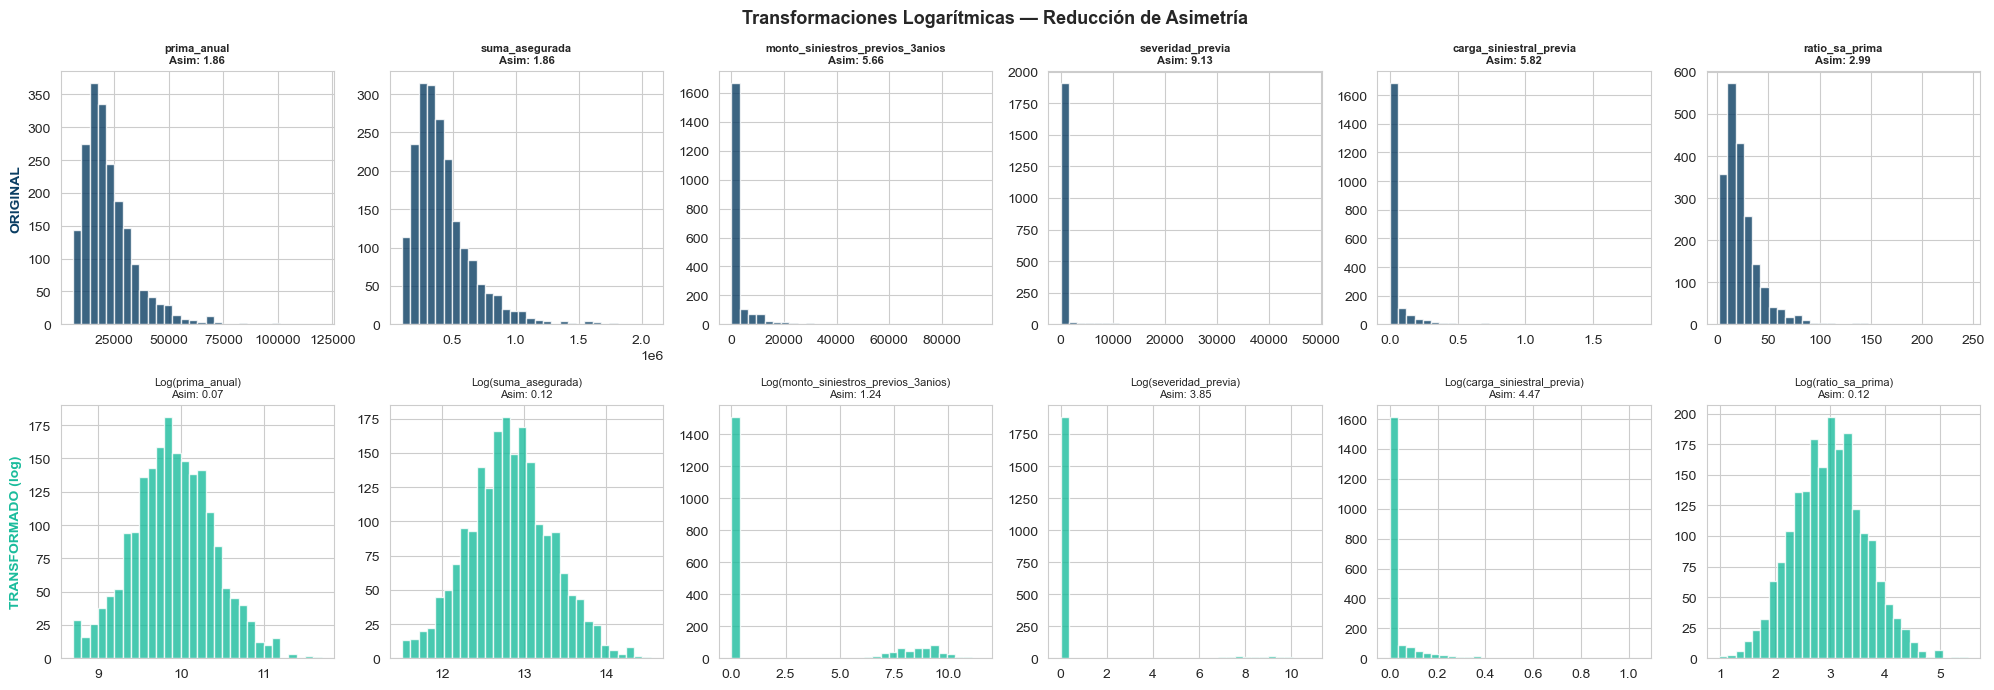

✅ Transformaciones aplicadas


In [ ]:
# ═══════════════════════════════════════════════════════
# PASO 5: TRANSFORMACIONES DE ASIMETRÍA (Tema 2.2)
# ═══════════════════════════════════════════════════════
print("🔧 PASO 5: Aplicando transformaciones a variables asimétricas...")

vars_a_transformar = {
    'prima_anual': 'log',
    'suma_asegurada': 'log',
    'monto_siniestros_previos_3anios': 'log',
    'severidad_previa': 'log',
    'carga_siniestral_previa': 'log',
    'ratio_sa_prima': 'log',
}

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
for i, (col, metodo) in enumerate(vars_a_transformar.items()):
    data = df[col].values
    skew_orig = pd.Series(data).skew()
    axes[0, i].hist(data, bins=30, color='#0A3D62', alpha=0.8, edgecolor='white')
    axes[0, i].set_title(f'{col}\nAsim: {skew_orig:.2f}', fontsize=8, fontweight='bold')
    
    # Aplicar transformación log
    transformed = np.log1p(data)
    skew_trans = pd.Series(transformed).skew()
    df[f'{col}_log'] = transformed
    axes[1, i].hist(transformed, bins=30, color='#1ABC9C', alpha=0.8, edgecolor='white')
    axes[1, i].set_title(f'Log({col})\nAsim: {skew_trans:.2f}', fontsize=8)

axes[0, 0].set_ylabel('ORIGINAL', fontweight='bold', color='#0A3D62')
axes[1, 0].set_ylabel('TRANSFORMADO (log)', fontweight='bold', color='#1ABC9C')
plt.suptitle('Transformaciones Logarítmicas — Reducción de Asimetría', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('transformaciones_globales.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Transformaciones aplicadas")


In [12]:
# ═══════════════════════════════════════════════════════
# PASO 6: ESCALAMIENTO (Tema 2.1)
# ═══════════════════════════════════════════════════════
print("🔧 PASO 6: Escalando variables numéricas...")

# Variables a escalar (ya transformadas o ya bien distribuidas)
vars_escalar_zscore = [
    'edad_conductor', 'exposicion_anios', 'antiguedad_cliente_anios',
    'antiguedad_vehiculo_anios', 'ncd_score', 'score_riesgo_total',
    'prima_anual_log', 'suma_asegurada_log', 'monto_siniestros_previos_3anios_log',
    'severidad_previa_log', 'carga_siniestral_previa_log', 'ratio_sa_prima_log',
    'tasa_prima', 
]

# Usar Z-Score para variables continuas
scaler = StandardScaler()
df_scaled = df[vars_escalar_zscore].copy()
df_scaled_arr = scaler.fit_transform(df_scaled.fillna(0))
df_scaled_df = pd.DataFrame(df_scaled_arr, columns=[f'{c}_scaled' for c in vars_escalar_zscore])

print("✅ Escalamiento aplicado")
print(f"   Variables escaladas: {len(vars_escalar_zscore)}")
print("\n   Estadísticas post-escalamiento (todas deben tener media≈0, std≈1):")
print(df_scaled_df.describe().round(3).to_string())


🔧 PASO 6: Escalando variables numéricas...
✅ Escalamiento aplicado
   Variables escaladas: 13

   Estadísticas post-escalamiento (todas deben tener media≈0, std≈1):
       edad_conductor_scaled  exposicion_anios_scaled  antiguedad_cliente_anios_scaled  antiguedad_vehiculo_anios_scaled  ncd_score_scaled  score_riesgo_total_scaled  prima_anual_log_scaled  suma_asegurada_log_scaled  monto_siniestros_previos_3anios_log_scaled  severidad_previa_log_scaled  carga_siniestral_previa_log_scaled  ratio_sa_prima_log_scaled  tasa_prima_scaled
count               2,000.00                 2,000.00                         2,000.00                          2,000.00          2,000.00                   2,000.00                2,000.00                   2,000.00                                    2,000.00                     2,000.00                            2,000.00                   2,000.00           2,000.00
mean                    0.00                     0.00                             0.00     

In [13]:
# ═══════════════════════════════════════════════════════
# PASO 7: CONSTRUIR DATASET FINAL
# ═══════════════════════════════════════════════════════
print("🔧 PASO 7: Construyendo dataset final para modelado...")

# Variables binarias (ya en escala 0/1, no necesitan escalamiento)
vars_binarias = ['es_renovacion', 'tiene_siniestro_previo', 'es_conductor_joven', 
                 'es_adulto_mayor', 'es_uso_comercial', 'vehiculo_antiguo', 'poliza_anual',
                 'inicio_en_temporada_alta', 'inicio_en_verano',
                 'sexo_M', 'cobertura_Amplia', 'cobertura_Total Plus',
                 'uso_Comercial', 'uso_Transporte',
                 'score_riesgo_edad', 'score_riesgo_vehiculo']

# Variable objetivo: ¿tuvo siniestro? (clasificación binaria)
df['target_siniestro'] = (df['num_siniestros'] > 0).astype(int)

# Unir todo
vars_binarias_existentes = [v for v in vars_binarias if v in df.columns]
df_final = pd.concat([
    df[['id_poliza', 'target_siniestro']],
    df_scaled_df,
    df[vars_binarias_existentes].reset_index(drop=True)
], axis=1)

df_final.columns = df_final.columns.str.replace(' ', '_').str.replace('+', 'plus')

print(f"📋 Dataset final: {df_final.shape[0]} filas x {df_final.shape[1]} columnas")
print(f"\n🎯 Variable objetivo:")
print(f"   Pólizas SIN siniestro: {(df_final['target_siniestro']==0).sum()} ({(df_final['target_siniestro']==0).mean()*100:.1f}%)")
print(f"   Pólizas CON siniestro: {(df_final['target_siniestro']==1).sum()} ({(df_final['target_siniestro']==1).mean()*100:.1f}%)")

print("\n📊 Primeras 3 filas del dataset final:")
print(df_final.head(3).to_string())

# Guardar
df_final.to_csv('dataset_final_modelado.csv', index=False)
print("\n✅ Dataset guardado como 'dataset_final_modelado.csv'")


🔧 PASO 7: Construyendo dataset final para modelado...
📋 Dataset final: 2000 filas x 26 columnas

🎯 Variable objetivo:
   Pólizas SIN siniestro: 1492 (74.6%)
   Pólizas CON siniestro: 508 (25.4%)

📊 Primeras 3 filas del dataset final:
     id_poliza  target_siniestro  edad_conductor_scaled  exposicion_anios_scaled  antiguedad_cliente_anios_scaled  antiguedad_vehiculo_anios_scaled  ncd_score_scaled  score_riesgo_total_scaled  prima_anual_log_scaled  suma_asegurada_log_scaled  monto_siniestros_previos_3anios_log_scaled  severidad_previa_log_scaled  carga_siniestral_previa_log_scaled  ratio_sa_prima_log_scaled  tasa_prima_scaled  es_renovacion  tiene_siniestro_previo  es_conductor_joven  es_adulto_mayor  es_uso_comercial  vehiculo_antiguo  poliza_anual  inicio_en_temporada_alta  inicio_en_verano  score_riesgo_edad  score_riesgo_vehiculo
0  POL-2024000                 1                   0.10                    -0.19                            -0.82                             -0.43        